# Testing Sparse Auto Encoder (SAE)

In principal, it should be possible to extract hidden feature vectors from embedding outputs using a sparse auto-encoder (SAE) to disentangle the superimposed features for a given set of neural activation outputs. To test the validity of using a SAE for this purpose, the code below trains one on some randomized vectors to assess whether the methods described in literature are enough to create sparsity in the feature layer of a 2-layer autoencoder.

*Note - This notebook was originally run on a gcloud instance with 32GB of memory. If you intend to re-run this notebook you will need similar compute and memory availability to avoid kernel crashes*

In [1]:
# imports
import tensorflow as tf
import keras
from keras import layers
import numpy as np
import pandas as pd
import Bio
import transformers
from objects.autoencoder import SparseAutoEncoder
import os

# data vis packages
import seaborn as sns
import matplotlib.pyplot as plt

2024-11-21 20:14:43.077597: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-21 20:14:43.086900: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-21 20:14:43.098015: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-21 20:14:43.101520: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-21 20:14:43.110936: I tensorflow/core/platform/cpu_feature_guar

### Train the Model

In [2]:
# create dataset from random tensors to test
SAE_name = 'autoencoder_test'
embed_length = 1024
ef = 4

print("=== Generating Test Data ===")
fake_embeddings = tf.random.uniform(shape=[10000, embed_length])
fake_dataset = tf.data.Dataset.from_tensor_slices((fake_embeddings, fake_embeddings)).batch(100)

print("=== Initializing Model ===")
# initialize the optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

# initialize the loss function
loss = keras.losses.MeanSquaredError()

# initialize the metrics
metrics = [
    keras.metrics.MeanSquaredError(),
    keras.metrics.Metric(name='placeholder') # placeholder for training, feature output requires a 2nd metric to appease keras
]

# compile the model
autoencoder = SparseAutoEncoder(encoding_size=embed_length, expansion_factor=ef)
autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

tb_callback = keras.callbacks.TensorBoard(log_dir=f'./logs/{SAE_name}', histogram_freq=5)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='mean_squared_error',
    min_delta=0.001,
    patience=10, 
    restore_best_weights=True
    )

print("=== Training Model ===")
history = autoencoder.fit(fake_dataset, epochs=100, callbacks=[tb_callback, early_stopping])

print("=== Saving Model ===")
path = f'./models/{SAE_name}.keras'

autoencoder.save(path)
autoencoder.save_weights(f'./models/{SAE_name}.weights.h5') # workaround via weight saving / loading

print(f"Model saved to: {path}")
print(autoencoder.summary())

=== Generating Test Data ===
=== Initializing Model ===
=== Training Model ===
Epoch 1/100


I0000 00:00:1732241684.787182   92213 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1732241684.820103   92213 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1732241684.820348   92213 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1732241684.821852   92213 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

 44/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 685.5198 - mean_squared_error: 0.3217

I0000 00:00:1732241687.189663   92309 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 544.8206 - mean_squared_error: 0.3261
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 90.2384 - mean_squared_error: 0.3093
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 89.1751 - mean_squared_error: 0.2744
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 83.7700 - mean_squared_error: 0.2544
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 81.8666 - mean_squared_error: 0.2459
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 83.4432 - mean_squared_error: 0.2123
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 83.5759 - mean_squared_error: 0.1929
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 82.6986 - mean_squared_error: 0.1865
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 83.5866 - mean_squared_error: 0.2101
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 83.5224 - mean_squared_error: 0.2158
Epoch 11/100
100/100 ━━━━━━━━

...

 Total params: 25,165,826 (96.00 MB)

 Trainable params: 8,388,608 (32.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,777,218 (64.00 MB)

None


### Examine Weights and their Distribution

The feature layer weights are an important component of SAEs since they represent the transformation of superimposed features to interpretable features. The weights in this layer therefore correlate with the relative feature importance of a given feature in the principal model's prediction.

In [3]:
feat_weights = np.array(autoencoder.weights[1])
print(feat_weights.shape)
agg_feat_weights = np.sum(feat_weights, axis=0)
feat_weights = feat_weights.flatten()
print(feat_weights.max())
print(feat_weights.min())

(4096, 1024)
0.2983843
-0.010568855


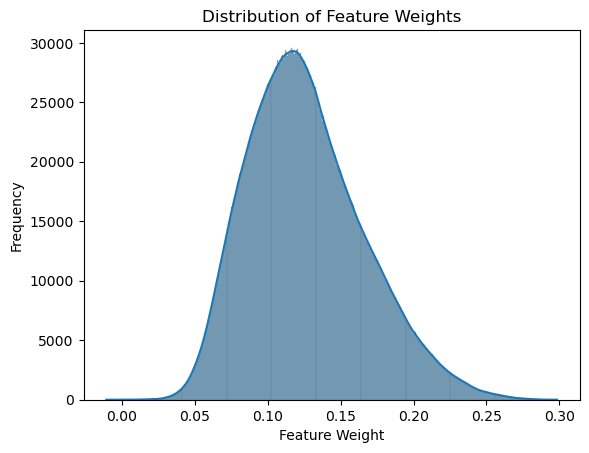

In [4]:
sns.histplot(feat_weights, kde=True)
plt.title('Distribution of Feature Weights')
plt.xlabel('Feature Weight')
plt.ylabel('Frequency')
plt.show()

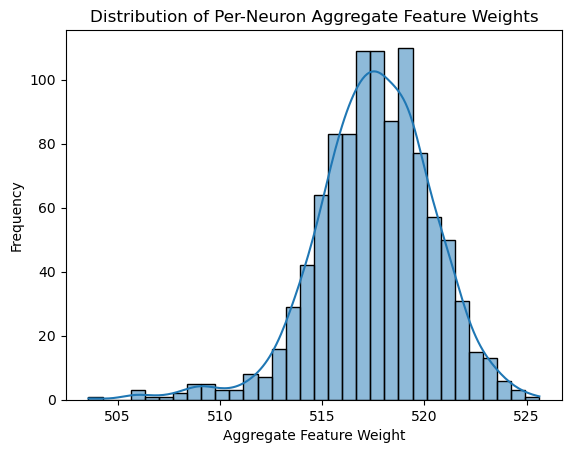

In [5]:
sns.histplot(agg_feat_weights, kde=True)
plt.title('Distribution of Per-Neuron Aggregate Feature Weights')
plt.xlabel('Aggregate Feature Weight')
plt.ylabel('Frequency')
plt.show()

### Examining Feature Layer for Sparsity

The key element of this model architecture for extracting features from a given neural network is the sparsity of neuron activations for a given input. Ideally, the SAE should learn to recognize the minimum number of basis directions needed to describe a given datapoint. While this would normally be an inefficient use of model parameters (i.e. the model would be way bigger than it needs to be), in this case it reduces the complexity of a given embedding to a handful of active features that we can hopefully correlate with observable phenomena.

In [6]:
autoencoder.predict_on_batch(fake_embeddings[:100])

(array([[0.31710076, 0.31581265, 0.30978537, ..., 0.3150103 , 0.32612276,
         0.32043955],
        [0.32607532, 0.32422483, 0.31835705, ..., 0.32333258, 0.33444917,
         0.32921547],
        [0.32924774, 0.32898566, 0.32256517, ..., 0.32857478, 0.3397119 ,
         0.33311307],
        ...,
        [0.3266411 , 0.3257834 , 0.31986684, ..., 0.3258209 , 0.3350469 ,
         0.33054575],
        [0.32050025, 0.31921548, 0.3131705 , ..., 0.318855  , 0.32947093,
         0.3240232 ],
        [0.34091282, 0.34065717, 0.33449423, ..., 0.34054872, 0.35078764,
         0.34619498]], dtype=float32),
 array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32))

In [7]:
reconstructed_outputs, feature_outputs = autoencoder.predict_on_batch(fake_embeddings[:100])

In [8]:
reconstructed_outputs

array([[0.31710076, 0.31581265, 0.30978537, ..., 0.3150103 , 0.32612276,
        0.32043955],
       [0.32607532, 0.32422483, 0.31835705, ..., 0.32333258, 0.33444917,
        0.32921547],
       [0.32924774, 0.32898566, 0.32256517, ..., 0.32857478, 0.3397119 ,
        0.33311307],
       ...,
       [0.3266411 , 0.3257834 , 0.31986684, ..., 0.3258209 , 0.3350469 ,
        0.33054575],
       [0.32050025, 0.31921548, 0.3131705 , ..., 0.318855  , 0.32947093,
        0.3240232 ],
       [0.34091282, 0.34065717, 0.33449423, ..., 0.34054872, 0.35078764,
        0.34619498]], dtype=float32)

In [9]:
feature_outputs

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [10]:
feature_outputs[0].sort()
print(feature_outputs[0][-20:])
print(feature_outputs.shape)

[0.03766301 0.03870301 0.03924011 0.03929602 0.039388   0.03945563
 0.04253722 0.04323762 0.04433958 0.04437217 0.0444503  0.04633372
 0.04639586 0.04878151 0.04987434 0.0513086  0.05279847 0.05319639
 0.05450195 0.05690276]
(100, 4096)


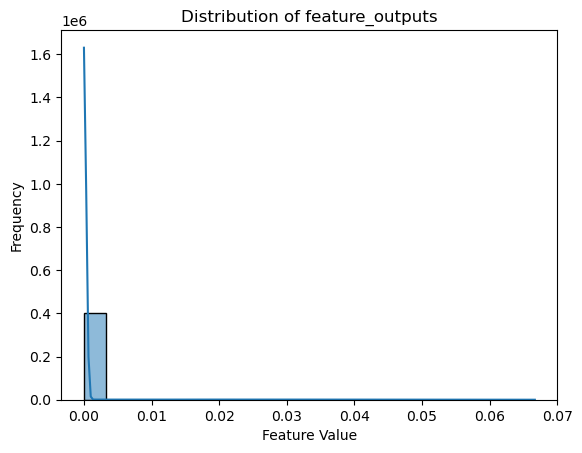

In [11]:
sns.histplot(feature_outputs.flatten(), kde=True)
plt.title('Distribution of feature_outputs')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.show()

This Elbow shape is exactly what we want.

### Check Model Fit / Overfit

In [12]:
# check model fit
fit_test_data = tf.random.uniform(shape=[100, embed_length])
fit_test_dataset = tf.data.Dataset.from_tensor_slices((fit_test_data, fit_test_data)).batch(10)

fit_test = autoencoder.evaluate(fit_test_dataset)
print(f"Loss: {fit_test[0]} | MSE: {fit_test[1]}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 85.2649 - mean_squared_error: 0.1125  
Loss: 85.26488494873047 | MSE: 0.11127515137195587


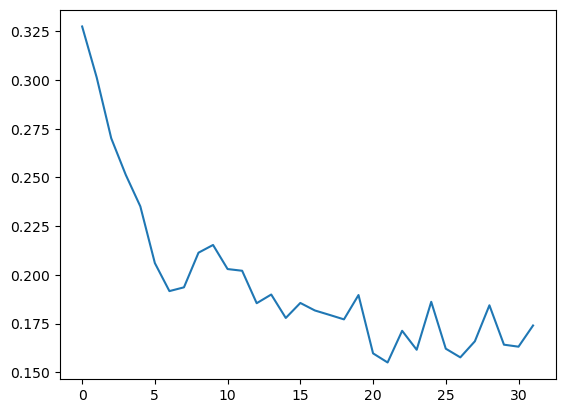

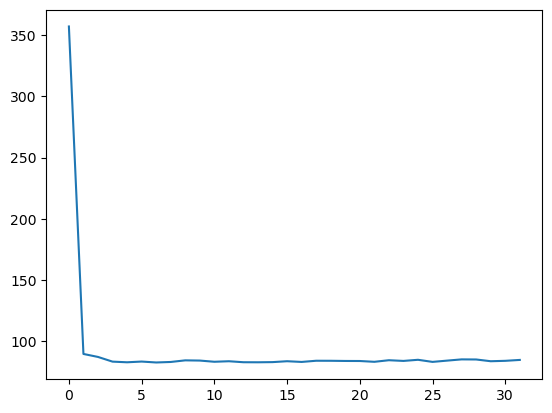

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['mean_squared_error'])
plt.show()
plt.plot(history.history['loss'])
plt.show()

### Exploring Orthogonality

Considering slices of the weight matrix as basis vectors pointing either toward the input space or toward the output space, the code below calculates the angle between each of these vectors and plots a histogram for both directions. Theoretically, an SAE which has learned to disentangle superimposed features should have smaller angles between the ouput vectors than the input vectors.

In this particular example, we don't observe this effect, and the vector angles are actually quite small. However, at the end of this notebook you do see a marked difference between the input and output vectors that might be worth exploring in further SAEs.

Input Vectors Shape:
(1024, 4096)
Output Vectors Shape:
(4096, 1024)
Calculating Input Angles...


100%|██████████| 1024/1024 [00:40<00:00, 25.09it/s]


Calculating Output Angles...


100%|██████████| 4096/4096 [00:40<00:00, 100.23it/s]


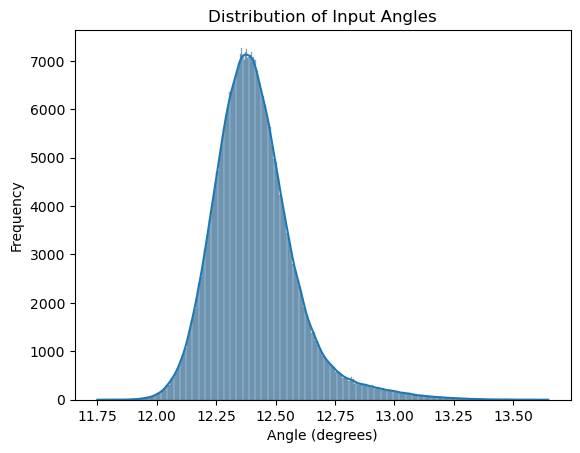

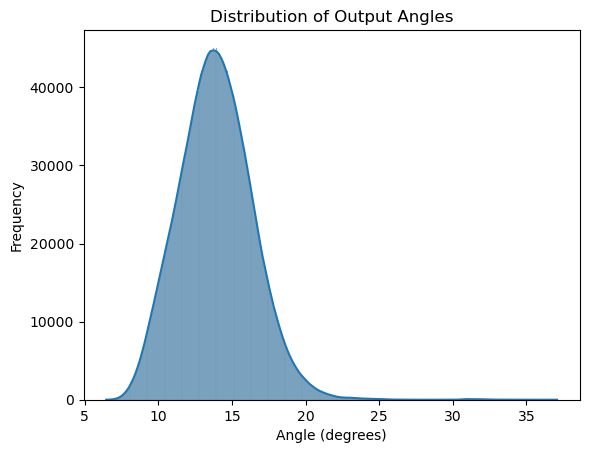

In [14]:
def vector_angle(v1, v2):
    """finds the angle between two vectors"""
    return np.arccos(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

def radians_to_degrees(radians):
    return radians * 180 / np.pi

feat_weights = np.array(autoencoder.weights[1])

input_vectors = feat_weights.T
output_vectors = feat_weights

del feat_weights
print("Input Vectors Shape:")
print(input_vectors.shape)
print("Output Vectors Shape:")
print(output_vectors.shape)

input_angles = []
output_angles = []

from tqdm import tqdm
print("Calculating Input Angles...")
for i, v1 in tqdm(enumerate(input_vectors), total=len(input_vectors)):
    for v2 in input_vectors[:i:]:
        input_angles.append(radians_to_degrees(vector_angle(v1, v2)))

print("Calculating Output Angles...")
for i, v1 in tqdm(enumerate(output_vectors), total=len(output_vectors)):
    for v2 in output_vectors[:i:]:
        output_angles.append(radians_to_degrees(vector_angle(v1, v2)))


# Plot histogram of input angles
sns.histplot(input_angles, kde=True)
plt.title('Distribution of Input Angles')
plt.xlabel('Angle (degrees)')
plt.ylabel('Frequency')
plt.show()

# Plot histogram of output angles
sns.histplot(output_angles, kde=True)
plt.title('Distribution of Output Angles')
plt.xlabel('Angle (degrees)')
plt.ylabel('Frequency')
plt.show()

In [15]:
# cleaning some memory
del fake_embeddings
del fake_dataset
del reconstructed_outputs, feature_outputs, fit_test, fit_test_data, fit_test_dataset
del autoencoder, loss, metrics, optimizer, SAE_name, embed_length, ef, tb_callback, early_stopping, history, path

# SAE on ESM Embeddings for Hemoglobin Variants

Using the embeddings we previously generated from ESM-2, we're going to extract per-residue features based on the superposition hypothesis. After a bit of reformatting the data for this purpose, we should be able to train it to decompose the 1280-dimensional embeddings into a given number of features (number of neurons in the feature/2nd layer). The weights approximate the importance of those features.

In [16]:
# load metadata
var_data = pd.read_csv('./data/hbvar-w-func-embed-seq.csv')
# pandas saves these as strings for some reason - reload from numpy
var_data.drop(columns=['embeddings', 'sequence_representation', 'esm_representation'], inplace=True)
# drop stuff we don't need right now
var_data.drop(columns=[
    'electrophoresisComment',
    'hgvsName',
    'chromatography',
    'dnaDescriptionComment',
    'aliases',
    'stability',
    'functionalComment',
    'variantComment',
    'Structure',
    'electrophoresis',
    'name'
    ],
    inplace=True
)

# explicitly match embeddings to sequences when re-loading
embeddings = [np.load(f"./data/variant_embeddings/all_vars/{j}.npy") for j in var_data["sequence"]]

# reduce jagged tensors and add to dataframe
def fix_jagged_2d(embed_list):
    sir_gallahad_the_chaste = []
    # find max length in 2nd dim (sequence length)
    max_len = max([len(arr[0]) for arr in embed_list])
    # append zero vector to embeddings
    for i, arr in enumerate(embed_list):
        if len(arr[0]) < max_len:
            padded = np.append(arr[0], np.zeros((max_len - len(arr[0]), 1280)), axis=0)
            sir_gallahad_the_chaste.append(np.expand_dims(padded, axis=0))
        else:
            sir_gallahad_the_chaste.append(arr)
    return sir_gallahad_the_chaste

embeddings = np.concatenate(fix_jagged_2d(embeddings))
var_data['embeddings'] = embeddings
print(embeddings.shape)

(1206, 148, 1280)


In [17]:
# create dataset for training SAE
def pad_sequences(amino_acid_seq:str, pad_length:int):
    if len(amino_acid_seq)==pad_length:
        return amino_acid_seq
    else:
        return amino_acid_seq+''.join(['-' for i in range(pad_length-len(amino_acid_seq))])

residue_embeddings = np.vstack(embeddings)
residue_labels = ''.join([pad_sequences(i, 148) for i in var_data['sequence']])
print(residue_embeddings.shape)
print(len(residue_labels))

(178488, 1280)
178488


In [18]:
embed_data = pd.DataFrame(residue_embeddings)
embed_data["residues"] = [i for i in residue_labels]
ids = []
for x in var_data['sequence']:
    for n in range(148):
        ids.append(x)
embed_data["id"] = ids
embed_data

,0,1,2,3,4,5,6,7,8,9,...,1272,1273,1274,1275,1276,1277,1278,1279,residues,id
0,0.039880,-0.060474,0.010107,0.036829,-0.108196,0.034697,0.064647,-0.159625,-0.046258,0.062892,...,-0.141350,0.002107,0.019046,-0.125863,-0.041022,-0.254396,0.179195,0.026323,M,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
1,0.080393,-0.052154,-0.171746,0.341434,0.078772,-0.058304,0.333229,-0.171261,-0.152863,0.206985,...,0.022498,0.101823,-0.029865,0.270576,-0.352361,0.134863,-0.125038,0.054623,G,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
2,-0.049513,0.014455,-0.113939,0.060111,-0.072646,-0.010627,0.273609,-0.318852,0.433905,0.061857,...,0.014927,0.150102,-0.240294,0.024542,0.329014,0.054479,0.119776,-0.048153,L,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
3,0.127423,-0.091589,0.235782,0.205985,0.035046,0.042871,0.346926,-0.112454,-0.497411,0.014614,...,-0.036321,0.142612,0.149523,-0.274964,0.304388,-0.278865,0.117745,-0.125761,S,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
4,-0.008895,-0.026455,-0.074877,0.359108,-0.062585,0.190984,0.031155,-0.140788,-0.187589,0.197234,...,0.101468,-0.070155,-0.134162,-0.248186,-0.223817,0.005409,-0.130158,-0.222160,P,MGLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPH...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178483,-0.012570,0.155609,0.086157,0.203023,-0.189751,-0.219611,-0.089043,0.141252,-0.281113,0.286330,...,0.209440,-0.015287,-0.029175,0.007206,-0.113142,-0.114191,-0.199395,-0.126701,S,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...
178484,0.157495,0.253602,0.138182,0.164223,-0.114125,0.041772,-0.272245,0.024113,-0.052295,-0.014184,...,0.064878,0.118406,-0.092403,-0.098055,-0.239957,0.003924,-0.059399,-0.180254,R,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...
178485,0.039321,0.246502,0.044173,-0.037274,-0.029826,0.237742,-0.124555,0.027676,-0.236433,0.184976,...,0.077372,0.051368,0.180057,0.124684,-0.093465,-0.041433,0.026563,0.055376,Y,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...
178486,0.065609,-0.021404,-0.343105,0.312501,-0.192077,0.259709,0.161792,0.007382,-0.082263,-0.003792,...,0.114312,-0.013490,-0.047376,0.030331,-0.233131,-0.246021,-0.036705,0.138261,H,MGHFTEEDKATITSLWGKVNVEHAGGETLGRLLVVYPWTQRFFDSF...


In [19]:
embed_data.describe()

,0,1,2,3,4,5,6,7,8,9,...,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279
count,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,...,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000,178488.000000
mean,-0.000321,-0.089101,-0.127451,0.055683,-0.067626,0.003107,0.044247,-0.210164,-0.081553,0.128086,...,0.030794,-0.082786,0.025145,0.011804,-0.032353,-0.024557,0.035952,-0.113467,0.046954,0.052721
std,0.139333,0.181482,0.157588,0.155847,0.161549,0.156526,0.180078,0.177094,0.204604,0.152807,...,0.187289,0.168520,0.158767,0.160560,0.166029,0.186679,0.164430,0.174293,0.167026,0.173409
min,-0.544558,-0.771582,-0.727541,-0.494625,-0.637256,-0.515902,-0.580913,-0.771121,-0.806071,-0.316211,...,-0.514649,-0.829288,-0.665902,-0.449860,-0.636442,-0.539795,-0.503426,-0.703602,-0.750693,-0.491891
25%,-0.084041,-0.207170,-0.227538,-0.039479,-0.173615,-0.114964,-0.086407,-0.333480,-0.210472,0.019621,...,-0.096063,-0.186588,-0.088813,-0.103231,-0.138652,-0.162429,-0.069913,-0.220089,-0.073394,-0.061247
50%,0.007769,-0.079225,-0.107067,0.040565,-0.065167,0.007672,0.041899,-0.201495,-0.074380,0.128690,...,0.023891,-0.077323,0.028429,0.007233,-0.040593,-0.017941,0.031843,-0.108067,0.044187,0.055111
75%,0.091808,0.040356,-0.024260,0.146942,0.027864,0.112802,0.158992,-0.081739,0.050357,0.233646,...,0.139286,0.014959,0.138188,0.121978,0.075068,0.112806,0.151372,0.000000,0.159136,0.170518
max,0.447940,0.429185,0.379090,0.724625,0.479238,0.466639,0.679860,0.421257,0.595878,0.665754,...,0.870759,0.483314,0.559513,0.594107,0.544495,0.582657,0.625675,0.466966,0.573696,0.591184


In [20]:
# just in case we want to reload / use this later
embed_data.to_csv("./data/heme_SAE_train.csv")

### Training the SAE

In [21]:
# cleaning some memory
del embed_data, embeddings, var_data

In [22]:
# key parameters, model name
SAE_name = 'ESM-2-1280d-SAE-ef4'
embed_length = 1280
ef = 4

print("=== Initializing Model ===")
# initialize the optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

# initialize the loss function
loss = keras.losses.MeanSquaredError(reduction='sum')

# initialize the metrics
metrics = [
    keras.metrics.MeanSquaredError(),
    keras.metrics.Metric(name='placeholder') # placeholder for training, feature output requires a 2nd metric to appease keras
]

# compile the model
autoencoder = SparseAutoEncoder(encoding_size=embed_length, expansion_factor=ef)
autoencoder.compile(optimizer=optimizer, loss=loss, metrics=metrics)

tb_callback = keras.callbacks.TensorBoard(log_dir=f'./logs/{SAE_name}', histogram_freq=5)
early_stopping = keras.callbacks.EarlyStopping(
    monitor='mean_squared_error',
    min_delta=0.001,
    patience=10, 
    restore_best_weights=True
    )

print("=== Training Model ===")
history = autoencoder.fit(
    x=residue_embeddings,
    y=residue_embeddings,
    batch_size=32, 
    epochs=100, 
    validation_split=0.1, 
    callbacks=[tb_callback, early_stopping]
    )

print("=== Saving Model ===")
path = f'./models/{SAE_name}.keras'

autoencoder.save(path)
autoencoder.save_weights(f'./models/{SAE_name}.weights.h5') # workaround via weight saving / loading

print(f"Model saved to: {path}")
print(autoencoder.summary())

=== Initializing Model ===
=== Training Model ===
Epoch 1/100


2024-11-21 20:20:15.798000: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 4 bytes spill stores, 4 bytes spill loads

2024-11-21 20:20:16.182111: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 144 bytes spill stores, 144 bytes spill loads

2024-11-21 20:20:16.292002: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 16 bytes spill stores, 16 bytes spill loads



5006/5020 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.1743 - mean_squared_error: 0.0717

2024-11-21 20:20:39.213956: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 4 bytes spill stores, 4 bytes spill loads

2024-11-21 20:20:39.651530: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 176 bytes spill stores, 176 bytes spill loads

2024-11-21 20:20:39.716492: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 16 bytes spill stores, 16 bytes spill loads

2024-11-21 20:20:39.882305: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_130', 44 bytes spill stores, 44 bytes spill loads



5020/5020 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31.1261 - mean_squared_error: 0.0717

...

 Total params: 39,321,602 (150.00 MB)

 Trainable params: 13,107,200 (50.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 26,214,402 (100.00 MB)

None


===== MSE =====


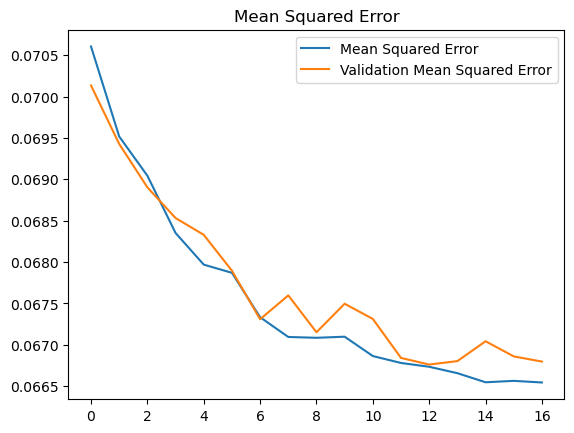

===== LOSS =====


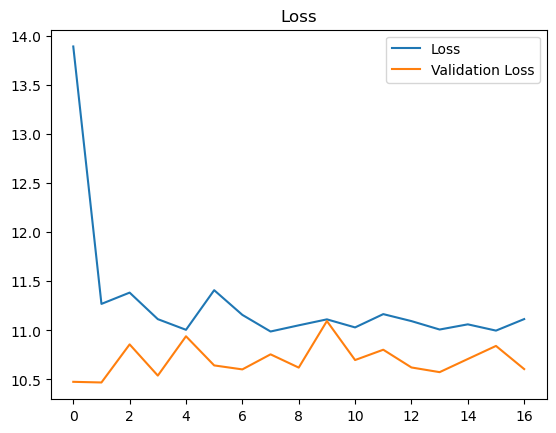

In [23]:
import matplotlib.pyplot as plt

print("===== MSE =====")
sns.lineplot(data=history.history['mean_squared_error'], label='Mean Squared Error')
sns.lineplot(history.history['val_mean_squared_error'], label='Validation Mean Squared Error')
plt.title("Mean Squared Error")
plt.show()

print("===== LOSS =====")
sns.lineplot(data=history.history['loss'], label='Loss')
sns.lineplot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.show()

### Feature Weights

Just like above, we have to look at the weights to see how the SAE is performing at its interpretability task. Note that negative weight values effectively correlate to non-useful features since the relu function drives negative neuron activations toward zero.

(5120, 1280)
21.805605
-17.42671


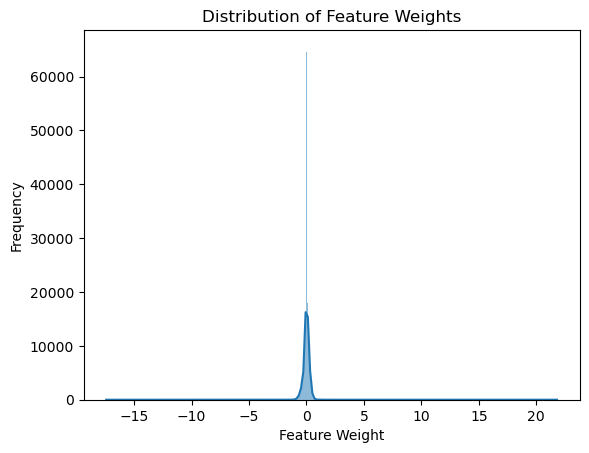

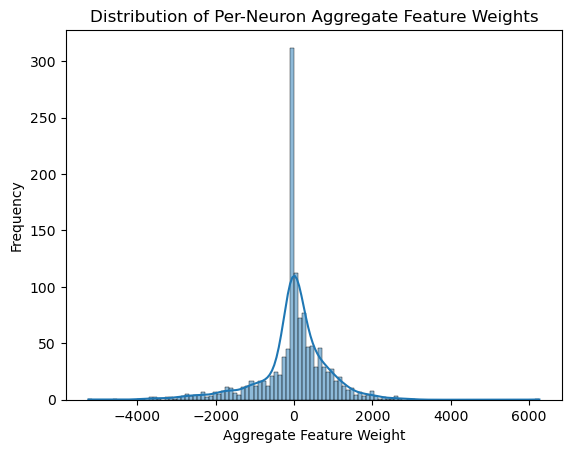

In [24]:
feat_weights = np.array(autoencoder.weights[1])
print(feat_weights.shape)
agg_feat_weights = np.sum(feat_weights, axis=0)
feat_weights = feat_weights.flatten()
print(feat_weights.max())
print(feat_weights.min())

sns.histplot(feat_weights, kde=True)
plt.title('Distribution of Feature Weights')
plt.xlabel('Feature Weight')
plt.ylabel('Frequency')
plt.show()

sns.histplot(agg_feat_weights, kde=True)
plt.title('Distribution of Per-Neuron Aggregate Feature Weights')
plt.xlabel('Aggregate Feature Weight')
plt.ylabel('Frequency')
plt.show()

### Sparsity

2024-11-21 20:27:34.929305: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 16 bytes spill stores, 16 bytes spill loads

2024-11-21 20:27:35.081826: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 176 bytes spill stores, 176 bytes spill loads

2024-11-21 20:27:35.094431: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 44 bytes spill stores, 44 bytes spill loads

2024-11-21 20:27:35.221705: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_13', 360 bytes spill stores, 276 bytes spill loads



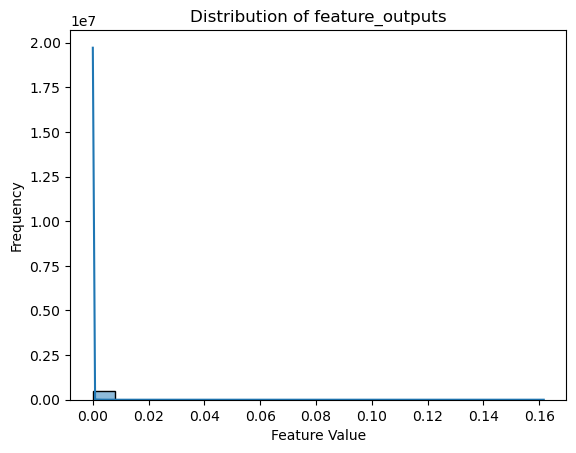

In [25]:
reconstructed_outputs, feature_outputs = autoencoder.predict_on_batch(residue_embeddings[:100])

sns.histplot(feature_outputs.flatten(), kde=True)
plt.title('Distribution of feature_outputs')
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.show()

# Exploring Orthogonality of Weight Vectors

Considering slices of the weight matrix as basis vectors pointing either toward the input space or toward the output space, the code below calculates the angle between each of these vectors and plots a histogram for both directions. Theoretically, an SAE which has learned to disentangle superimposed features should have smaller angles between the ouput vectors than the input vectors.

Unlike the toy example above, we see that the input vector angles cluster much closer to 90 degrees (orthogonal), and the output vectors cluster closer to 60 degrees, which, indicates a degree of positive interference and supports the superposition hypothesis.

Input Vectors Shape:
(1280, 5120)
Output Vectors Shape:
(5120, 1280)
Calculating Input Angles...


100%|██████████| 1280/1280 [01:08<00:00, 18.63it/s]


Calculating Output Angles...


100%|██████████| 5120/5120 [01:06<00:00, 76.73it/s] 


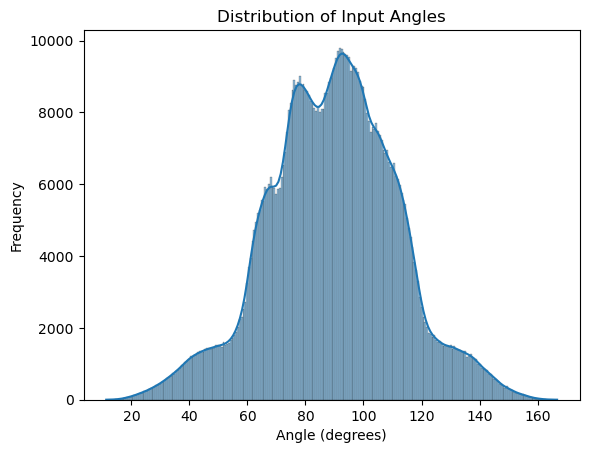

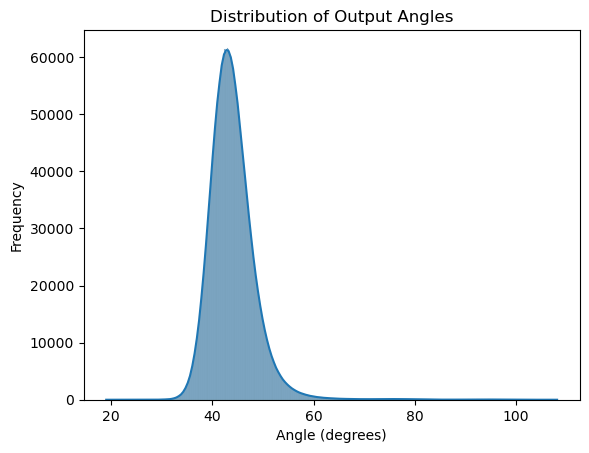

In [26]:
def vector_angle(v1, v2):
    """finds the angle between two vectors"""
    return np.arccos(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))

def radians_to_degrees(radians):
    return radians * 180 / np.pi

feat_weights = np.array(autoencoder.weights[1])

input_vectors = feat_weights.T
output_vectors = feat_weights

del feat_weights
print("Input Vectors Shape:")
print(input_vectors.shape)
print("Output Vectors Shape:")
print(output_vectors.shape)

input_angles = []
output_angles = []

from tqdm import tqdm
print("Calculating Input Angles...")
for i, v1 in tqdm(enumerate(input_vectors), total=len(input_vectors)):
    for v2 in input_vectors[:i:]:
        input_angles.append(radians_to_degrees(vector_angle(v1, v2)))

print("Calculating Output Angles...")
for i, v1 in tqdm(enumerate(output_vectors), total=len(output_vectors)):
    for v2 in output_vectors[:i:]:
        output_angles.append(radians_to_degrees(vector_angle(v1, v2)))


# Plot histogram of input angles
sns.histplot(input_angles, kde=True)
plt.title('Distribution of Input Angles')
plt.xlabel('Angle (degrees)')
plt.ylabel('Frequency')
plt.show()

# Plot histogram of output angles
sns.histplot(output_angles, kde=True)
plt.title('Distribution of Output Angles')
plt.xlabel('Angle (degrees)')
plt.ylabel('Frequency')
plt.show()